In [34]:
# Importing Libraries
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

from IPython.display import display, Markdown
from dotenv import load_dotenv
load_dotenv()

True

In [35]:
# Defining LLM Model
MODEL_NAME = 'gpt-4o-mini'
model = ChatOpenAI(model=MODEL_NAME)

In [36]:
# Define the state
class BlogState(TypedDict):
    title: str
    outline:str
    content: str

In [37]:
def create_outline(state:BlogState) -> BlogState:
    # Fetch the title
    title = state['title']

    # call the llm gen outline
    prompt = PromptTemplate(template="Generate a detailed outline for a blog on the topic - {title}",
                            input_variables=['title'])
    
    # Parser to fetch the output
    str_parser = StrOutputParser()
    outline_workflow = prompt | model | str_parser 

    # get the outline from LLM
    outline = outline_workflow.invoke({'title': title})

    # update the state
    state['outline'] = outline 

    return state

In [38]:
def create_blog(state:BlogState)->BlogState:

    # Fetch the title and outline from state
    title = state['title']
    outline = state['outline']

    # prepare the prompt
    prompt = PromptTemplate(template="Write a detailed blog on title - {title} using the following outline \n{outline}",
                            input_variables=['title', 'outline'])
    
    # blog workflow
    blog_workflow = prompt | model | StrOutputParser()

    # blog content 
    content = blog_workflow.invoke({
        'title': title, 'outline': outline
    })

    # update the state 
    state['content'] = content
    
    return state

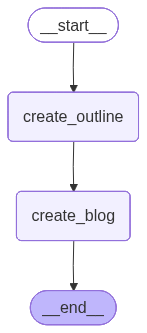

In [39]:
# Create graph
graph = StateGraph(BlogState)

# Define the nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# Define the edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

# compile the graph
graph.compile()

In [40]:
# create the workflow
workflow = graph.compile()

# initial state
initial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(initial_state)

In [41]:
display(Markdown(final_state['title']))

Rise of AI in India

In [42]:
# Outline
display(Markdown(final_state['outline']))

# Outline for Blog: The Rise of AI in India

## Introduction
- **Hook**: Engage readers with a compelling statistic or fact about AI’s growth in India.
- **Background**: Brief overview of what AI is and its global significance.
- **Thesis Statement**: Outline how India is becoming a key player in the AI landscape, highlighting its potential and current trends.

## Section 1: The Current State of AI in India
### 1.1 Overview of AI Development
- Definition and explanation of AI, machine learning, and data science.
- Current capabilities of AI technologies being used in India.

### 1.2 Key Players and Contributors
- Government initiatives: National AI Strategy and Digital India Campaign.
- Private sector involvement: Major tech companies (TCS, Infosys, Wipro, etc.) and their AI ventures.
- Startups thriving in the AI space.

### 1.3 Research and Academic Institutions
- Highlight leading universities and institutions driving AI research (IITs, IISc, etc.).
- Contributions from think tanks and research organizations.

## Section 2: Sectors Driving AI Adoption
### 2.1 Healthcare
- Applications of AI in diagnostics, telemedicine, and drug discovery.
- Case studies of successful AI healthcare implementations.

### 2.2 Agriculture
- Use of AI for predictive analytics, crop management, and yield optimization.
- Examples of AI solutions assisting farmers in India.

### 2.3 Finance
- AI in fintech: Fraud detection, credit scoring, and robo-advisors.
- Transformation of traditional banking through AI technology.

### 2.4 Education
- Personalization of learning experiences using AI.
- AI tools used in online and offline educational settings.

### 2.5 Transportation and Logistics
- AI in smart cities, autonomous vehicles, and logistics optimization.
- Impact on urban infrastructure and transportation systems.

## Section 3: Challenges Faced in AI Implementation
### 3.1 Infrastructure Limitations
- Internet access issues, especially in rural areas.
- Need for computing resources and data availability.

### 3.2 Skill Gap
- Overview of the current workforce's readiness for AI roles.
- Initiatives to bridge the skill gap through education and training.

### 3.3 Ethical and Regulatory Concerns
- Data privacy issues and the need for regulations.
- Addressing biases in AI algorithms and ensuring transparency.

### 3.4 Public Acceptance and Trust
- Concerns about job displacement and security implications.
- Strategies to increase public awareness and acceptance of AI technologies.

## Section 4: Future of AI in India
### 4.1 Growth Projections
- Predicted growth rates of AI in India over the next decade.
- Economic impact and benefits to society.

### 4.2 Government Initiatives and Policies
- Upcoming policies aimed at fostering AI development.
- Investments in AI research and infrastructure.

### 4.3 Collaborations and Partnerships
- Importance of partnerships between government, academia, and industry.
- Global collaborations that could position India as a leading AI hub.

## Conclusion
- **Summary**: Recap of the rise of AI in India and its potential.
- **Call to Action**: Encourage readers to stay informed and consider the implications of AI in their fields.
- **Closing Thought**: Reflect on the transformative potential of AI for India's future and its role in global innovation.

## Additional Resources
- Links to recent reports, articles, and studies on AI in India.
- Recommendations for further reading and exploration on AI technologies and their impact. 

## Comments Section
- Invite readers to share their thoughts and experiences with AI in India.

In [43]:
# Blog content
display(Markdown(final_state['content']))

# The Rise of AI in India

## Introduction

Did you know that the artificial intelligence (AI) market in India is expected to reach a staggering $7.8 billion by 2025? This explosive growth reflects not just an increase in interest but also significant investments and innovations within the country. AI, a subset of computer science that empowers machines to mimic human intelligence, has become a global leader in enhancing productivity, efficiency, and decision-making.

In recent years, India has emerged as a critical player in the global AI landscape, leveraging its vast data resources, technical talent, and robust talent pool to drive advancements in AI technologies. This blog will explore the current state of AI in India, sectors leading the charge, challenges faced, future projections, and the crucial role of government, academia, and industry in shaping this exciting field.

## Section 1: The Current State of AI in India

### 1.1 Overview of AI Development

AI encompasses various technologies, including machine learning (ML) and data science, which enable systems to analyze information, learn from it, and make informed decisions. In India, the current capabilities of AI span across numerous applications, from chatbots improving customer service to advanced analytics transforming business strategies. The Indian ecosystem is witnessing innovations that show immense promise in various sectors, underscoring the country's potential to be at the forefront of AI development.

### 1.2 Key Players and Contributors

The Indian government has laid the groundwork for AI advancements through critical initiatives. The National AI Strategy, introduced by NITI Aayog, aims to position India as a leader in AI by fostering innovation, research, and deployment across sectors. Complementing this is the Digital India Campaign, which seeks to improve digital infrastructure and enhance access to technology.

Private sector involvement is robust, with major tech firms like TCS, Infosys, and Wipro investing heavily in AI capabilities. Startups, such as Niramai (healthcare) and CropIn (agriculture), are also flourishing, spurring progress and contributing to a vibrant AI ecosystem.

### 1.3 Research and Academic Institutions

Leading institutions such as Indian Institutes of Technology (IITs) and the Indian Institute of Science (IISc) are at the forefront of AI research. Their contributions have been pivotal in driving innovations in machine learning, robotics, and data analytics. Think tanks and research organizations, including the Centre for Artificial Intelligence and Robotics (CAIR), are also making significant strides, providing valuable insights that enhance India’s AI landscape.

## Section 2: Sectors Driving AI Adoption

### 2.1 Healthcare

AI’s role in healthcare is transformative. Applications such as AI-driven diagnostics and telemedicine are revolutionizing patient care. For example, companies like SigTuple and Niramai utilize AI to analyze medical data and improve diagnostic accuracy. The ability of AI to sift through massive datasets quickly allows healthcare professionals to make informed decisions, improving patient outcomes.

### 2.2 Agriculture

AI is also making waves in agriculture, where predictive analytics help farmers assess weather patterns and crop health. Solutions like AgroStar offer AI-powered recommendations for effective farming practices, significantly enhancing yield optimization and resource management.

### 2.3 Finance

In the finance sector, AI is reshaping the landscape through advanced algorithms for fraud detection, credit scoring, and establishing personal finance management tools like robo-advisors. Traditional banking is evolving with AI-enabled chatbots and personalized banking experiences, enhancing customer engagement and operational efficiency.

### 2.4 Education

AI-driven platforms in education provide personalized learning experiences, adapting to students' needs. Institutions are implementing AI tools like intelligent tutoring systems and learning management systems that analyze student performance data, enhancing educational outcomes.

### 2.5 Transportation and Logistics

AI technologies in transportation include smart traffic management, logistics optimization, and even autonomous vehicles. Innovators are leveraging AI to improve urban infrastructure, streamline supply chain processes, and increase public transport efficiency.

## Section 3: Challenges Faced in AI Implementation

### 3.1 Infrastructure Limitations

Despite rapid growth, AI implementation faces significant hurdles, notably infrastructure limitations. Internet access, especially in rural areas, creates a digital divide, hampering the deployment of AI solutions. Computing resources and data availability are also critical challenges that need addressing.

### 3.2 Skill Gap

There exists a pronounced skill gap in the workforce regarding AI roles, with numerous positions unfilled due to the shortage of trained professionals. To remediate this, educational institutions and initiatives like the Skills Development Mission are stepping in to equip individuals with the necessary skills.

### 3.3 Ethical and Regulatory Concerns

As AI becomes more integrated into everyday life, ethical considerations, including data privacy and algorithmic biases, become paramount. There is a pressing need for regulatory frameworks to ensure transparency and the protection of individuals’ rights.

### 3.4 Public Acceptance and Trust

Public concerns surrounding job displacement and security implications raise skepticism regarding AI adoption. Addressing these fears through awareness campaigns and educating the public about the benefits of AI is vital for fostering trust and acceptance.

## Section 4: Future of AI in India

### 4.1 Growth Projections

The AI market in India is projected to grow CAGR of over 40% in the coming years, driven by increased investments from both the government and private sectors. This growth is poised to have significant economic implications, with the potential to generate millions of jobs and drive innovation across industries.

### 4.2 Government Initiatives and Policies

The Indian government is expected to roll out additional policies aimed at supporting the AI ecosystem, focusing on research funding, talent development, and infrastructure improvements. Sustained investments will be crucial to maintaining the momentum in AI development.

### 4.3 Collaborations and Partnerships

Encouraging collaborations between government, academia, and industry will be vital for fostering innovation and leveraging collective expertise. International partnerships can also elevate India’s position as a leading AI hub on the global stage.

## Conclusion

The rise of AI in India signifies a promising future filled with opportunities and advancements that can elevate various sectors. It is essential for stakeholders—governments, industries, and individuals—to remain informed and engaged with AI's rapid evolution and its implications. The transformative potential of AI can fundamentally alter everyday life and elevate India’s status in the global innovation landscape. 

## Additional Resources

For those looking to dive deeper into the world of AI in India, here are some valuable resources:
- [NITI Aayog's National AI Strategy Report](https://niti.gov.in/writereaddata/files/document_publication/NationalAIStrategyReport.pdf)
- [Gartner Report on AI Trends](https://www.gartner.com/en/newsroom/press-releases/2020-04-10-gartner-says-three-technology-trends-at-the-core-of-the-march-2020-coronavirus-pandemic-will-serve-as-a-bright-spot-for-global-income-in-2020)
- [AI in India: Opportunities and Threats](https://www.worldbank.org/en/news/feature/2020/06/10/ai-in-india)

## Comments Section

I invite you to share your thoughts and experiences regarding AI in India. What impacts have you witnessed? How do you think AI can reshape industries in the coming years? Let’s engage in a fruitful discussion.

In [44]:
import os
output_file = 'essay.txt'
with open(output_file, 'w') as file:
    file.write(final_state['content'])